<a href="https://colab.research.google.com/github/PatChizzy/Workshop/blob/master/ClassExercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scenario Analytics Lab: Irrigation Planning Under Weather Stress

| Task | Activity |
| --- | --- |
| **1. Investigate the selected station** | Aggregate the station observations into a complete daily dataset and identify periods of unusually high temperature or rainfall. |
| **2. Compute reference evapotranspiration (ET₀)** | Calculate daily ET₀ using the provided FAO-56 Penman-Monteith implementation and identify the day with the highest atmospheric water demand. |
| **3. Generate crop-season data** | Construct the supplied crop growth stages, generate daily crop coefficients (Kc), calculate crop evapotranspiration (ETc), and compare crop-cycle characteristics. |
| **4. Simulate weather scenarios** | Calculate irrigation requirements under baseline, heat-wave (+4 °C), and no-effective-rainfall drought conditions, and compare seasonal changes across crops. |
| **5. Diagnose growth-stage and location effects** | Compare irrigation demand across growth stages, scenarios, crops, and stations, and identify the conditions associated with the greatest irrigation demand. |
| **6. Make a management recommendation** | Summarize the main irrigation-demand findings and recommend a practical management action supported by numerical evidence from the analysis. |

Complete the tasks sequentially in the notebook. Your outputs will be personalized using your student information and selected station.

## Student Personalization <a name="return"></a>

In [ ]:
# Replace with your own details
student_name = "ENTER YOUR FULL NAME"
student_id = "ENTER YOUR STUDENT ID"

# Select one station: A, B, or C
station_choice = "ENTER A, B, OR C"

In [ ]:
# DO NOT EDIT THIS CELL
student_name = str(student_name).strip()
student_id = str(student_id).strip()
station_choice = str(station_choice).strip().upper()


# Validate personalization
defaults = {
    "student_name": "ENTER YOUR FULL NAME",
    "student_id": "ENTER YOUR STUDENT ID",
    "station_choice": "ENTER A, B, OR C"}

valid_stations = {"A", "B", "C"}

personalized = (
    student_name != ""
    and student_id != ""
    and station_choice != ""
    and student_name != defaults["student_name"]
    and student_id != defaults["student_id"]
    and station_choice != defaults["station_choice"]
    and station_choice in valid_stations)


if not personalized:
    print("Personalization not completed correctly.\n"
        "Please enter your full name, student ID, and a station from A to C "
        "in the personalization cell above, then run both cells again.")

else:
    # Dataset stationName
    selected_station = f"Station_{station_choice}"


    # Add personalization to every figure
    def personalize_figure(fig, filename, station=None):
        station_label = station or selected_station

        fig.text(0.5, 0.01, f"{student_name} - {student_id} (Exploring {station_label})", ha="center", va="bottom", fontsize=10, fontweight="bold", fontstyle="italic")
        fig.subplots_adjust(bottom=0.15)

        # Save the personalized figure
        fig. savefig(f"{filename}.png", dpi=300, bbox_inches="tight")
        print(f"Saved: {filename}.png")

    # Confirm student information
    print(
        "Student Information\n"
        "----------------------------------------\n"
        f"Name:             {student_name}\n"
        f"Student ID:       {student_id}\n"
        f"Selected Station: {selected_station}\n"
        "----------------------------------------\n"
        "Personalization completed successfully.")

## How to use this notebook

Most code is complete and demonstrates the method. A small number of lines are marked **TODO — YOUR TURN**.

For each TODO:

1. read the completed lines around it;
2. use the hint immediately above the missing line;
3. replace `YOUR_CODE_HERE` with valid Python;
4. run the cell and check the output before continuing.

The missing lines are intentionally placed throughout the lesson. Later cells may depend on them, so complete each TODO in order.


# Import Modules

In [ ]:
# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Utilities
import warnings
import textwrap

# Display settings
warnings.filterwarnings("ignore")

# Import Data

In [ ]:
df = pd.read_csv('https://weatherdata.sfo3.digitaloceanspaces.com/weather_station_anonymized.csv')

## Explore Data

In [ ]:
# Display column names available
df.columns

In [ ]:
# Display the first five observations
df.head()

In [ ]:
# Check the number of observations and variables
print(f"Number of observations: {df.shape[0]:,}")
print(f"Number of variables: {df.shape[1]}")

In [ ]:
# Convert timestamp from text to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Confirm the conversion
df.dtypes

In [ ]:
# Identify the first and last timestamps in the dataset
print(f"Start: {df['timestamp'].min()}")
print(f"End:   {df['timestamp'].max()}")

In [ ]:
# Count the observations recorded at each station
df["stationName"].value_counts().sort_index()

In [ ]:
# Count missing values in each variable
df.isna().sum()

In [ ]:
# Examine the distribution and range of the weather variables
df.describe().round(2)

## Create Variables

In [ ]:
# Create new time-based variables from timestamp

# Calendar date of each observation — example completed for you
df["date"] = df["timestamp"].dt.date

# TODO — YOUR TURN: create the month name.
# Hint: follow the date example and use .dt.month_name() or .dt.month
df["month"] = YOUR_CODE_HERE

# Day of the week — another completed example
df["dayOfWeek"] = df["timestamp"].dt.day_name()


In [ ]:
# Compare the original timestamp with the new variables
df[["timestamp", "date", "month", "dayOfWeek"]].sample(5)

In [ ]:
# Calculate simple weather statistics
print(f"Mean temperature: {df['airTemperature'].mean():.2f} °C")

# TODO — YOUR TURN: complete the method used to find the maximum.
# Hint: the method name is max().
print(f"Maximum temperature: {df['airTemperature'].YOUR_CODE_HERE:.2f} °C")

# TODO — YOUR TURN: calculate total precipitation.
# Hint: a total uses sum().
print(f"Total precipitation: {df['precipitation'].YOUR_CODE_HERE:.2f} mm")


# Task 1: Investigate the Selected Station

In [ ]:
# Aggregate sub-hourly observations into daily weather conditions
# All stations are retained for later location comparisons

daily_weather = (
    df.groupby(
        ["stationName", "date", "month", "dayOfWeek"],
        as_index=False).agg(
        solarRadiation=("solarRadiation", "mean"),
        precipitation=("precipitation", "sum"),
        windSpeed=("windSpeed", "mean"),
        airTemperature=("airTemperature", "mean"),
        vaporPressure=("vaporPressure", "mean"),
        atmosphericPressure=("atmosphericPressure", "mean")))

daily_weather.head()

In [ ]:
# Create a view of your selected station
# The complete daily_weather dataset remains unchanged

selected_daily = (daily_weather[daily_weather["stationName"] == selected_station]
    .copy()
    .sort_values("date")
    .reset_index(drop=True))

print(f"Exploring: {selected_station}")
print(f"Number of days: {len(selected_daily)}")
print(f"Period: {selected_daily['date'].min()} "f"to {selected_daily['date'].max()}")

In [ ]:
# Plot all daily weather variables for the selected station
variables = [("solarRadiation", "Solar Radiation"),
            ("windSpeed", "Wind Speed"),
            ("vaporPressure", "Vapor Pressure"),
            ("atmosphericPressure", "Atmospheric Pressure")]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

axes = axes.flatten()

for ax, (variable, label) in zip(axes, variables):

    ax.plot(selected_daily["date"], selected_daily[variable], linewidth=1.2)
    ax.set_title(label)
    ax.set_ylabel(label)
    ax.grid(alpha=0.2)

# Label the x-axis on the bottom plots
axes[-2].set_xlabel("Date")
axes[-1].set_xlabel("Date")

# Add an overall title
fig.suptitle(f"Daily Weather Profile: {selected_station}", fontsize=14, fontweight="bold")

# Adjust spacing
fig.tight_layout(rect=[0, 0.04, 1, 0.96])

# Add student name, ID, and station
personalize_figure(fig, "01_daily_weather_profile")

plt.show()

In [ ]:
# Calculate the 90th-percentile temperature threshold for each station
# This is the worked example.
temp_thresholds = (
    daily_weather.groupby("stationName")["airTemperature"]
    .quantile(0.90)
    .rename("tempThreshold")
)

# TODO — YOUR TURN: adapt the temperature example for rainfall.
# Important: use rainy days only, where precipitation > 0.
rain_thresholds = (
    daily_weather[YOUR_CODE_HERE]
    .groupby("stationName")["precipitation"]
    .quantile(YOUR_CODE_HERE)
    .rename("rainThreshold")
)

# Add the thresholds to the complete daily dataset
daily_weather = daily_weather.merge(temp_thresholds, on="stationName", how="left")
daily_weather = daily_weather.merge(rain_thresholds, on="stationName", how="left")

# Temperature flag — worked example
daily_weather["highTemperature"] = (
    daily_weather["airTemperature"] > daily_weather["tempThreshold"]
)

# TODO — YOUR TURN: create the equivalent rainfall flag.
daily_weather["highRainfall"] = YOUR_CODE_HERE


In [ ]:
# Refresh the selected-station view with the new threshold variables
selected_daily = (daily_weather[daily_weather["stationName"] == selected_station]
    .copy()
    .sort_values("date")
    .reset_index(drop=True))

# Display the thresholds for the selected station
print(f"High-temperature threshold: "f"{selected_daily['tempThreshold'].iloc[0]:.2f} °C")
print( f"High-rainfall threshold: "f"{selected_daily['rainThreshold'].iloc[0]:.2f} mm")

In [ ]:
# Extract unusually hot and unusually wet days at the selected station
high_temp = selected_daily[selected_daily["highTemperature"]]
high_rain = selected_daily[selected_daily["highRainfall"]]

# Create the figure
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Temperature
axes[0].plot(selected_daily["date"], selected_daily["airTemperature"], linewidth=1.3, label="Daily Mean Temperature")
axes[0].axhline(selected_daily["tempThreshold"].iloc[0], linestyle="--", linewidth=1.2, label="90th Percentile")
axes[0].scatter(high_temp["date"], high_temp["airTemperature"], s=35, zorder=3, label="Unusually High")
axes[0].set_ylabel("Air Temperature (°C)")
axes[0].set_title("Unusually High Temperature")
axes[0].legend()
axes[0].grid(alpha=0.2)

# Rainfall
axes[1].bar(selected_daily["date"], selected_daily["precipitation"], alpha=0.6, label="Daily Precipitation")
axes[1].axhline(selected_daily["rainThreshold"].iloc[0], linestyle="--", linewidth=1.2, label="90th Percentile")
axes[1].scatter(high_rain["date"], high_rain["precipitation"], s=35, zorder=3, label="Unusually High")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Precipitation (mm)")
axes[1].set_title("Unusually High Rainfall")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.2)

# Overall title
fig.suptitle(f"Temperature and Rainfall Extremes: {selected_station}", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0.04, 1, 0.96])

# Add student personalization
personalize_figure(fig, "02_temperature_rainfall_extremes")
plt.show()

# Task 2: Compute Reference Evapotranspiration

Reference evapotranspiration (**ET₀**) represents the atmospheric demand for water from a standardized reference surface. It provides a common measure of how strongly the atmosphere is drawing water from the land surface under the observed weather conditions.

Daily ET₀ is estimated using a **data-constrained FAO-56 Penman-Monteith approach**:

$$
ET_0 =
\frac{
0.408\Delta(R_n-G)
+
\gamma\frac{900}{T+273}u_2(e_s-e_a)
}{
\Delta+\gamma(1+0.34u_2)
}
$$

where:

| Parameter | Meaning | Source in this analysis |
| --- | --- | --- |
| $ET_0$ | Reference evapotranspiration (mm day$^{-1}$) | Calculated |
| $T$ | Mean daily air temperature (°C) | `airTemperature` |
| $u_2$ | Mean daily wind speed at 2 m (m s$^{-1}$) | `windSpeed` |
| $e_s$ | Saturation vapour pressure (kPa) | Calculated from `airTemperature` |
| $e_a$ | Actual vapour pressure (kPa) | `vaporPressure` |
| $e_s-e_a$ | Vapour pressure deficit (kPa) | Calculated |
| $\Delta$ | Slope of the saturation vapour pressure curve (kPa °C$^{-1}$) | Calculated from `airTemperature` |
| $\gamma$ | Psychrometric constant (kPa °C$^{-1}$) | Calculated from `atmosphericPressure` |
| $R_n$ | Net radiation (MJ m$^{-2}$ day$^{-1}$) | Approximated from `solarRadiation` |
| $G$ | Soil heat flux (MJ m$^{-2}$ day$^{-1}$) | Assumed to be 0 for daily calculations |

**Derived Parameters and Constants**

**1.** Saturation vapour pressure represents the maximum water-vapour pressure possible at the observed air temperature:

$$
e_s =
0.6108
\exp\left(
\frac{17.27T}{T+237.3}
\right)
$$

**2.** Slope of the saturation vapour pressure curve

$$
\Delta =
\frac{
4098e_s
}{
(T+237.3)^2
}
$$

**3.** Psychrometric constant is calculated from atmospheric pressure:

$$
\gamma = 0.000665P
$$

where $P$ is atmospheric pressure in kPa.

**4.** Vapour pressure deficit is the difference between saturation and actual vapour pressure

$$
VPD = e_s-e_a
$$


**5.** Net-Radiation is approximated from the observed solar radiation using the reference-surface albedo:

$$
R_n \approx (1-\alpha)R_s
$$

where:

- $R_s$ = observed solar radiation
- $\alpha$ = surface albedo
- $\alpha = 0.23$ for the FAO reference grass surface

Therefore:

$$
R_n \approx 0.77R_s
$$

This is a simplified, data-constrained approximation because net longwave radiation is not explicitly calculated. ET₀ values should therefore be interpreted within the assumptions of this exercise.

> **Note:** For daily calculations, soil heat flux is assumed to be negligible:

$$
G \approx 0
$$

## Objective

Calculate daily ET₀ for all stations, then use your selected station to:

1. examine how atmospheric water demand changes over the observation period;
2. identify the day with the **highest ET₀**; and
3. report the corresponding ET₀ value in **mm/day**.

In [ ]:
# Calculate parameters required for FAO-56 ET0
# Mean daily air temperature (°C)
T = daily_weather["airTemperature"]

# Saturation vapour pressure (kPa)
daily_weather["es"] = (0.6108 * np.exp((17.27 * T) / (T + 237.3)))

# Slope of the saturation vapour pressure curve (kPa/°C)
daily_weather["delta"] = (4098 * daily_weather["es"] / (T + 237.3) ** 2)

# Convert atmospheric pressure from hPa to kPa
daily_weather["pressure_kPa"] = (daily_weather["atmosphericPressure"] / 10)

daily_weather["gamma"] = (0.000665 * daily_weather["pressure_kPa"]) # Psychrometric constant (kPa/°C)

# Convert actual vapour pressure from Pa to kPa
daily_weather["ea"] = (daily_weather["vaporPressure"] / 1000)

# Vapour pressure deficit (kPa)
daily_weather["VPD"] = (daily_weather["es"] - daily_weather["ea"]).clip(lower=0)

In [ ]:
# Approximate daily net radiation

# FAO reference-surface albedo
albedo = 0.23

# Approximate net radiation (MJ/m²/day)
daily_weather["Rn"] = ((1 - albedo) * daily_weather["solarRadiation"])

# Daily soil heat flux is assumed to be negligible
G = 0

In [ ]:
# Calculate daily reference evapotranspiration (ET0)

u2 = daily_weather["windSpeed"]

daily_weather["ET0"] = ((0.408 * daily_weather["delta"] * (daily_weather["Rn"] - G)
                        + daily_weather["gamma"] * (900 / (T + 273)) * u2 * daily_weather["VPD"])
                        / (daily_weather["delta"] + daily_weather["gamma"] * (1 + 0.34 * u2)))

In [ ]:
# Extract ET0 results for the selected station

selected_daily = (daily_weather[
        daily_weather["stationName"] == selected_station]
    .copy()
    .sort_values("date")
    .reset_index(drop=True))

selected_daily[["date", "airTemperature", "VPD", "Rn", "ET0"]].head()

In [ ]:
# Find the day with the highest ET0 at the selected station
# Worked example:
max_et0_day = selected_daily.loc[selected_daily["ET0"].idxmax()]

# TODO — YOUR TURN: adapt the line above to find the minimum ET0 day.
# Hint: change only the method that identifies the index.
min_et0_day = YOUR_CODE_HERE

In [ ]:
# Plot daily reference evapotranspiration
fig, ax = plt.subplots(figsize=(12, 5))

# Shade the area under the ET0 curve
ax.fill_between(selected_daily["date"], selected_daily["ET0"], alpha=0.20)

# Plot daily ET0
ax.plot(selected_daily["date"], selected_daily["ET0"], linewidth=1.5, label="Daily ET₀")

# Highlight the highest ET0
ax.scatter(max_et0_day["date"], max_et0_day["ET0"], s=90, color="black", marker="^", zorder=4,
           label=(f"Highest: {max_et0_day['ET0']:.2f} mm/day " f"({max_et0_day['date']})"))

# Highlight the lowest ET0
ax.scatter(min_et0_day["date"], min_et0_day["ET0"], s=90, color="black", marker="v", zorder=4,
           label=(f"Lowest: {min_et0_day['ET0']:.2f} mm/day "f"({min_et0_day['date']})"))

# Labels and formatting
ax.set_title(f"Atmospheric Water Demand: {selected_station}", fontweight="bold", pad=40)
ax.set_xlabel("Date")
ax.set_ylabel("Reference Evapotranspiration, ET₀ (mm/day)")

# Start ET0 axis at zero
ax.set_ylim(bottom=0)

# Horizontal grid only
ax.grid(axis="y", alpha=0.2)

# Legend placed above the plot
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=True)

# Figure spacing
fig.subplots_adjust(top=0.78,bottom=0.16)

# Personalize and save
personalize_figure(fig, "03_reference_evapotranspiration")
plt.show()

## Task 3: Generate Crop-Season Data

Crop water demand changes throughout the growing season. The FAO-56 single crop coefficient approach represents this change using a **crop coefficient ($K_c$)**.

Crop evapotranspiration is calculated as:

$$
ET_c = K_c \times ET_0
$$

where:

- $ET_c$ = crop evapotranspiration (mm day$^{-1}$)
- $K_c$ = crop coefficient
- $ET_0$ = reference evapotranspiration (mm day$^{-1}$)

**Crop Growth Stages**

Each crop is divided into four growth stages:

1. **Initial:** $K_c$ remains at the initial crop coefficient, $K_{c,ini}$.
2. **Development:** $K_c$ gradually changes from $K_{c,ini}$ to $K_{c,mid}$.
3. **Mid-season:** $K_c$ remains at the mid-season coefficient, $K_{c,mid}$.
4. **Late season:** $K_c$ gradually changes from $K_{c,mid}$ to $K_{c,end}$.

The crop parameters used in this analysis are:

| Crop | Initial (days) | Development (days) | Mid (days) | Late (days) | Total (days) | $K_{c,ini}$ | $K_{c,mid}$ | $K_{c,end}$ |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| Rice | 30 | 30 | 60 | 30 | 150 | 1.05 | 1.20 | 0.75 |
| Millet | 15 | 25 | 40 | 25 | 105 | 0.35 | 1.00 | 0.30 |
| Maize | 30 | 50 | 60 | 40 | 180 | 0.30 | 1.20 | 0.60 |
| Tomato | 30 | 40 | 40 | 25 | 135 | 0.45 | 1.152 | 0.80 |
| Cucumber | 20 | 30 | 40 | 15 | 105 | 0.50 | 1.00 | 0.90 |

Each crop begins on the first day of the selected station's weather record and uses the number of consecutive weather days required by its crop-cycle length.

# Objective

Using your selected station:

1. construct the four growth stages for **all five crops**;
2. generate daily $K_c$ values throughout each crop cycle;
3. calculate daily crop evapotranspiration, $ET_c$;
4. compare crop-cycle lengths and stage durations; and
5. compare how $K_c$ and crop water demand differ among the five crops.

In [ ]:
# Define crop growth-stage durations and crop coefficients
CROPS = {
    "Rice": {
        "lengths": [30, 30, 60, 30],
        "kc": [1.05, 1.20, 0.75]
    },
    "Millet": {
        "lengths": [15, 25, 40, 25],
        "kc": [0.35, 1.00, 0.30]
    },
    "Maize": {
        "lengths": [30, 50, 60, 40],
        "kc": [0.30, 1.20, 0.60]
    },
    "Tomato": {
        "lengths": [30, 40, 40, 25],
        "kc": [0.45, 1.152, 0.80]
    },
    "Cucumber": {
        "lengths": [20, 30, 40, 15],
        "kc": [0.50, 1.00, 0.90]
    }
}

STAGE_NAMES = ["Initial", "Development", "Mid", "Late"]

In [ ]:
# Create a summary of crop-cycle characteristics
crop_summary = []

for crop_name, parameters in CROPS.items():

    initial, development, mid, late = parameters["lengths"]
    kc_initial, kc_mid, kc_end = parameters["kc"]

    crop_summary.append({
        "Crop": crop_name,
        "Initial": initial,
        "Development": development,
        "Mid": mid,
        "Late": late,
        "TotalCycle": initial + development + mid + late,
        "Kc_initial": kc_initial,
        "Kc_mid": kc_mid,
        "Kc_end": kc_end
    })

crop_summary = pd.DataFrame(crop_summary)
crop_summary

In [ ]:
# Visualize crop-cycle and growth-stage durations using distinct patterns

fig, ax = plt.subplots(figsize=(10, 6))

stage_patterns = {"Initial": "**",
                "Development": "--",
                "Mid": ".oo,",
                "Late": "x-x-"}

left = np.zeros(len(crop_summary))

for stage in STAGE_NAMES:

    ax.barh(
        crop_summary["Crop"],
        crop_summary[stage],
        left=left,
        label=stage,
        color="white",
        edgecolor="black",
        hatch=stage_patterns[stage],
        linewidth=0.7)

    left += crop_summary[stage].to_numpy()


# Title and labels
ax.set_title("Crop Cycle and Growth-Stage Durations", fontweight="bold")
ax.set_xlabel("Duration (days)")
ax.set_ylabel("Crop")


# Light grid behind the bars
ax.grid(axis="x", alpha=0.15, linewidth=0.7)
ax.set_axisbelow(True)

# Legend at bottom right
ax.legend(title="Growth Stage", loc="lower right", frameon=True)

# Personalize and save
personalize_figure(fig, "04_crop_growth_stage_durations")
plt.show()

In [ ]:
# Generate daily Kc values and growth-stage labels for each crop
def crop_curve(crop_name):

    # Get the four growth-stage durations
    initial, development, mid, late = CROPS[crop_name]["lengths"]

    # Get the initial, mid-season, and end-season Kc values
    kc_initial, kc_mid, kc_end = CROPS[crop_name]["kc"]

    # Construct the daily Kc curve
    kc = np.concatenate([
        np.full(initial, kc_initial),
        np.linspace(kc_initial, kc_mid, development, endpoint=False),
        np.full(mid, kc_mid),
        np.linspace(kc_mid, kc_end, late)])

    # Assign a growth stage to every crop day
    stages = np.repeat(STAGE_NAMES, [initial, development, mid, late])

    return kc, stages

In [ ]:
# Generate crop-season data for all five crops using weather from the selected station

crop_results = []

for crop_name in CROPS:

    # Total crop-cycle length
    number_of_days = sum(CROPS[crop_name]["lengths"])

    # Confirm that enough weather data are available
    if len(selected_daily) < number_of_days:
        raise ValueError(
            f"{crop_name} requires {number_of_days} days, "
            f"but only {len(selected_daily)} days are available.")

    # Use the required number of consecutive weather days
    crop_data = (
        selected_daily
        .head(number_of_days)
        .copy()
        .reset_index(drop=True))

    # Generate crop coefficient and growth stages
    kc, stages = crop_curve(crop_name)

    # Add crop-season information
    crop_data["crop"] = crop_name
    crop_data["cropDay"] = np.arange(1, number_of_days + 1)
    crop_data["stage"] = stages
    crop_data["Kc"] = kc

    crop_results.append(crop_data)

# Combine all crops
crop_season = pd.concat(crop_results, ignore_index=True)

In [ ]:
# Compare crop coefficient curves for all five crops

fig, ax = plt.subplots(figsize=(12, 4))

for crop_name in CROPS:

    crop_data = crop_season[crop_season["crop"] == crop_name]

    ax.plot(crop_data["cropDay"], crop_data["Kc"], linewidth=2, label=crop_name)

ax.set_title(f"Crop Coefficient Curves: {selected_station}", fontweight="bold")
ax.set_xlabel("Crop Day")
ax.set_ylabel("Crop Coefficient, Kc")

# Place the legend at the bottom right
ax.legend(title="Crop", loc="lower right", ncol=5, fontsize=7, title_fontsize=8)
ax.grid(alpha=0.2)

personalize_figure(fig, "05_crop_coefficient_curves")
plt.show()

In [ ]:
# Calculate daily crop evapotranspiration for all five crops

# TODO — YOUR TURN
# Formula: ETc = Kc × ET0
crop_season["ETc"] = YOUR_CODE_HERE

# Preview the calculated crop evapotranspiration
crop_season[["date", "crop", "cropDay", "stage", "Kc", "ET0", "ETc"]].head(10)


In [ ]:
# Compare mid-season crop coefficients

kc_mid_summary = (
    crop_summary[
        ["Crop", "Kc_mid"]
    ]
    .sort_values("Kc_mid", ascending=False)
    .reset_index(drop=True)
)

kc_mid_summary

In [ ]:
# Compare crop-cycle lengths, stage durations, and mid-season coefficients

crop_comparison = (
    crop_summary[
        [
            "Crop",
            "Initial",
            "Development",
            "Mid",
            "Late",
            "TotalCycle",
            "Kc_mid"
        ]
    ]
    .copy()
)

# Rename columns for clearer output
crop_comparison.columns = [
    "Crop",
    "Initial (days)",
    "Development (days)",
    "Mid (days)",
    "Late (days)",
    "Total Cycle (days)",
    "Mid-Season Kc"
]

crop_comparison

# Task 4: Simulate Weather Scenarios

Irrigation demand depends on both **crop water use** and the amount of water supplied naturally through rainfall. In this task, three weather conditions are evaluated for all five crops at the selected station.

**Gross Irrigation Requirement**

Net irrigation requirement represents the amount of water that must reach the crop root zone. Irrigation systems are not perfectly efficient, so more water must be supplied.

Assuming an irrigation efficiency of 75%:

$$
GIR = \frac{NIR}{0.75}
$$

where $GIR$ is the gross irrigation requirement (mm day$^{-1}$).

### Objective

For all five crops at your selected station:

1. calculate daily net and gross irrigation requirements under baseline conditions;
2. recalculate ET₀ and irrigation demand under the +4 °C heat-wave scenario;
3. simulate drought by setting effective rainfall to zero;
4. calculate seasonal irrigation totals for each crop and scenario; and
5. quantify the absolute and percentage change in irrigation demand relative to baseline.

### 1. Baseline Scenario

The baseline represents the observed weather conditions.

Observed precipitation is treated as effective rainfall for this teaching analysis.

$$
ET_{c,baseline} = K_c \times ET_0
$$

Daily net irrigation requirement is:

$$
NIR_{baseline} = \max(ET_{c,baseline} - P,\ 0)
$$

where:

- $NIR$ = net irrigation requirement (mm day$^{-1}$)
- $ET_c$ = crop evapotranspiration (mm day$^{-1}$)
- $P$ = effective rainfall (mm day$^{-1}$)

The maximum function prevents irrigation requirement from becoming negative when rainfall exceeds crop water demand.

In [ ]:
# Irrigation efficiency assumed for this teaching analysis
irrigation_efficiency = 0.75

In [ ]:
# BASELINE SCENARIO = Observed weather + observed rainfall
# Treat observed precipitation as effective rainfall
crop_season["effectiveRain_baseline"] = crop_season["precipitation"]

# Calculate daily net irrigation requirement
crop_season["NIR_baseline"] = (crop_season["ETc"] - crop_season["effectiveRain_baseline"]).clip(lower=0)

# Account for irrigation-system efficiency
crop_season["GIR_baseline"] = (crop_season["NIR_baseline"] / irrigation_efficiency)

In [ ]:
# Summarize baseline irrigation demand for each crop
baseline_summary = (crop_season.groupby("crop", as_index=False).agg(
        CropDays=("cropDay", "count"),
        TotalETc=("ETc", "sum"),
        EffectiveRain=("effectiveRain_baseline", "sum"),
        NetIrrigation=("NIR_baseline", "sum"),
        GrossIrrigation=("GIR_baseline", "sum")))

baseline_summary.round(2)

## 2. Heat-Wave Scenario

The heat-wave scenario represents a controlled sensitivity test in which observed air temperature is increased by **4 °C**, while the other measured weather variables remain unchanged.

$$
T_{heat} = T + 4
$$

Reference evapotranspiration is then recalculated using the modified temperature:

$$
ET_{0,heat} = f(T+4,\ R_n,\ u_2,\ e_a,\ P)
$$

Crop evapotranspiration under the heat-wave scenario becomes:

$$
ET_{c,heat} = K_c \times ET_{0,heat}
$$

The observed precipitation remains available under this scenario:

$$
NIR_{heat} = \max(ET_{c,heat} - P,\ 0)
$$

This is a sensitivity experiment rather than a complete physical heat-wave simulation because temperature is changed while the other observed weather variables are held constant.

In [ ]:
# HEAT-WAVE SCENARIO = Increase observed air temperature by 4 °C
crop_season["T_heat"] = (crop_season["airTemperature"] + 4)

# Recalculate saturation vapour pressure
crop_season["es_heat"] = (0.6108 * np.exp((17.27 * crop_season["T_heat"]) / (crop_season["T_heat"] + 237.3)))

# Recalculate the slope of the saturation vapour pressure curve
crop_season["delta_heat"] = (4098 * crop_season["es_heat"] / (crop_season["T_heat"] + 237.3) ** 2)

# Recalculate vapour pressure deficit
crop_season["VPD_heat"] = (crop_season["es_heat"] - crop_season["ea"]).clip(lower=0)

In [ ]:
# Recalculate reference evapotranspiration under heat-wave conditions
crop_season["ET0_heat"] = ((0.408 * crop_season["delta_heat"] * (crop_season["Rn"] - G) +
                            crop_season["gamma"] * (900 / (crop_season["T_heat"] + 273))
                            * crop_season["windSpeed"] * crop_season["VPD_heat"]) /
                           (crop_season["delta_heat"] + crop_season["gamma"] * (1 + 0.34 * crop_season["windSpeed"])))

crop_season["ET0_heat"] = (crop_season["ET0_heat"].clip(lower=0))

In [ ]:
# Compare mean atmospheric water demand
print("Mean Reference Evapotranspiration")
print("-" * 45)

print(f"Baseline:  " f"{crop_season['ET0'].mean():.2f} mm/day")
print(f"Heat wave: " f"{crop_season['ET0_heat'].mean():.2f} mm/day")

In [ ]:
# Calculate crop evapotranspiration under heat-wave conditions
crop_season["ETc_heat"] = (crop_season["Kc"] * crop_season["ET0_heat"])

# Rainfall remains unchanged
crop_season["NIR_heat"] = (crop_season["ETc_heat"] - crop_season["precipitation"]).clip(lower=0)

# Gross irrigation requirement
crop_season["GIR_heat"] = (crop_season["NIR_heat"] / irrigation_efficiency)

In [ ]:
# Summarize heat-wave irrigation demand by crop
heat_summary = (crop_season.groupby("crop", as_index=False).agg(
        BaselineET0=("ET0", "mean"),
        HeatWaveET0=("ET0_heat", "mean"),
        BaselineGIR=("GIR_baseline", "sum"),
        HeatWaveGIR=("GIR_heat", "sum")))

heat_summary.round(2)

## 3. Drought Scenario

The drought scenario assumes that **no effective rainfall is available** to meet crop water demand.

Reference evapotranspiration remains unchanged from the baseline:

$$
ET_{0,drought} = ET_0
$$

but:

$$
P_{effective} = 0
$$

Therefore:

$$
NIR_{drought} = ET_{c,baseline}
$$

In [ ]:
# DROUGHT SCENARIO = Assume no rainfall
crop_season["effectiveRain_drought"] = 0

# ETc remains unchanged from baseline
crop_season["ETc_drought"] = crop_season["ETc"]

# With no effective rainfall, crop water demand
# must be supplied through irrigation
crop_season["NIR_drought"] = (crop_season["ETc_drought"])

# Account for irrigation efficiency
crop_season["GIR_drought"] = (crop_season["NIR_drought"] / irrigation_efficiency)

In [ ]:
# Compare baseline and drought irrigation demand
drought_summary = (crop_season.groupby("crop", as_index=False).agg(
        BaselineRain=("effectiveRain_baseline", "sum"),
        DroughtRain=("effectiveRain_drought", "sum"),
        BaselineGIR=("GIR_baseline", "sum"),
        DroughtGIR=("GIR_drought", "sum")))

drought_summary.round(2)

In [ ]:
# Calculate seasonal gross irrigation totals
# for all crops under all three scenarios

seasonal_irrigation = (crop_season.groupby("crop", as_index=False).agg(
        Baseline=("GIR_baseline", "sum"),
        HeatWave=("GIR_heat", "sum"),
        Drought=("GIR_drought", "sum")))

seasonal_irrigation[["Baseline", "HeatWave", "Drought"]] = seasonal_irrigation[["Baseline", "HeatWave", "Drought"]].round(2)
seasonal_irrigation

In [ ]:
# Visualize seasonal irrigation demand under the three weather scenarios
fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(seasonal_irrigation))
width = 0.24

ax.bar(x - width, seasonal_irrigation["Baseline"], width, label="Baseline")
ax.bar(x, seasonal_irrigation["HeatWave"], width, label="Heat Wave (+4 °C)")
ax.bar(x + width, seasonal_irrigation["Drought"], width, label="Drought")

ax.set_title(f"Seasonal Irrigation Requirement: {selected_station}", fontweight="bold")
ax.set_xlabel("Crop")
ax.set_ylabel("Gross Irrigation Requirement (mm)")

ax.set_xticks(x)
ax.set_xticklabels(seasonal_irrigation["crop"])
ax.legend(title="Scenario", loc="upper left")
ax.grid(axis="y", alpha=0.15)

ax.set_axisbelow(True)

personalize_figure(fig, "06_seasonal_irrigation_scenarios")

plt.show()

In [ ]:
# Calculate absolute changes from baseline — completed examples
seasonal_irrigation["HeatWaveChange"] = (
    seasonal_irrigation["HeatWave"] - seasonal_irrigation["Baseline"]
)
seasonal_irrigation["DroughtChange"] = (
    seasonal_irrigation["Drought"] - seasonal_irrigation["Baseline"]
)

# TODO — YOUR TURN: convert both absolute changes to percentages.
# Formula: percentage change = change / baseline × 100
seasonal_irrigation["HeatWaveChange_pct"] = YOUR_CODE_HERE
seasonal_irrigation["DroughtChange_pct"] = YOUR_CODE_HERE


In [ ]:
# Display seasonal scenario changes

scenario_comparison = seasonal_irrigation[[
        "crop",
        "Baseline",
        "HeatWave",
        "HeatWaveChange",
        "HeatWaveChange_pct",
        "Drought",
        "DroughtChange",
        "DroughtChange_pct"]].copy()

scenario_comparison.columns = [
    "Crop",
    "Baseline GIR (mm)",
    "Heat-Wave GIR (mm)",
    "Change (mm)",
    "Change (%)",
    "Drought GIR (mm)",
    "Drought Change (mm)",
    "Drought Change (%)"]

scenario_comparison.round(2)

## Task 5: Diagnose Growth-Stage Demand

Irrigation demand varies across crop growth stages, weather conditions, and locations. This task examines these differences using the **Initial, Development, Mid, and Late** growth stages under **Baseline, Heat-Wave, and Drought** conditions.

The analysis also compares each crop at the selected station with an assigned comparison station.

### Objectives

1. Compare irrigation demand during the four growth stages for every crop and scenario.
2. Compare daily irrigation demand for the same crops at the selected and comparison stations.
3. Identify the crop, growth stage, scenario, and location associated with the greatest irrigation demand.

In [ ]:
# Calculate gross irrigation demand during each growth stage
# for every crop and weather scenario

stage_demand = (
    crop_season
    .groupby(
        ["crop", "stage"],
        as_index=False
    )
    .agg(
        Baseline=("GIR_baseline", "sum"),
        HeatWave=("GIR_heat", "sum"),
        Drought=("GIR_drought", "sum")
    )
)

# Round irrigation demand for easier interpretation
stage_demand[
    ["Baseline", "HeatWave", "Drought"]
] = stage_demand[
    ["Baseline", "HeatWave", "Drought"]
].round(2)

In [ ]:
# Arrange growth-stage demand as a comparison table

stage_demand_table = (
    stage_demand
    .melt(
        id_vars=["crop", "stage"],
        value_vars=["Baseline", "HeatWave", "Drought"],
        var_name="Scenario",
        value_name="GrossIrrigation"
    )
    .pivot(
        index=["crop", "Scenario"],
        columns="stage",
        values="GrossIrrigation"
    )
    .reindex(columns=STAGE_NAMES)
    .reset_index()
)

# Add total irrigation demand across all growth stages
stage_demand_table["Total"] = (
    stage_demand_table[STAGE_NAMES].sum(axis=1)
)

stage_demand_table

In [ ]:
# Convert stage demand to long format
stage_demand_long = stage_demand.melt(
    id_vars=["crop", "stage"],
    value_vars=["Baseline", "HeatWave", "Drought"],
    var_name="Scenario",
    value_name="GrossIrrigation"
)

# TODO — YOUR TURN: select the row with the greatest GrossIrrigation.
# Hint: use the pattern table.loc[table["column"].idxmax()].
highest_stage_demand = YOUR_CODE_HERE

print("Highest Growth-Stage Irrigation Demand")
print("-" * 45)
print(f"Station:  {selected_station}")
print(f"Crop:     {highest_stage_demand['crop']}")
print(f"Stage:    {highest_stage_demand['stage']}")
print(f"Scenario: {highest_stage_demand['Scenario']}")
print(f"Demand:   {highest_stage_demand['GrossIrrigation']:.2f} mm")


In [ ]:
# Assign a station for location comparison

comparison_map = {
    "Station_A": "Station_B",
    "Station_B": "Station_C",
    "Station_C": "Station_A"
}

comparison_station = comparison_map[selected_station]

print("Location Comparison")
print("-" * 40)
print(f"Selected station:   {selected_station}")
print(f"Comparison station: {comparison_station}")

In [ ]:
# Generate crop and scenario results for a station
def generate_station_scenarios(station_name):

    # Get daily weather for the requested station
    station_daily = (daily_weather[daily_weather["stationName"] == station_name].copy()
        .sort_values("date").reset_index(drop=True))

    results = []

    for crop_name in CROPS:
        # Crop-cycle length
        number_of_days = sum(CROPS[crop_name]["lengths"])

        # Use the required number of weather days
        crop_data = (station_daily.head(number_of_days).copy().reset_index(drop=True))

        # Generate Kc and growth stages
        kc, stages = crop_curve(crop_name)

        crop_data["crop"] = crop_name
        crop_data["cropDay"] = np.arange(1, number_of_days + 1)

        crop_data["stage"] = stages
        crop_data["Kc"] = kc

        # Baseline (real observation)
        crop_data["ETc"] = (crop_data["Kc"] * crop_data["ET0"])

        crop_data["GIR_baseline"] = ((crop_data["ETc"] - crop_data["precipitation"])
            .clip(lower=0) / irrigation_efficiency)

        # Heat wave
        crop_data["T_heat"] = (crop_data["airTemperature"] + 4)
        crop_data["es_heat"] = ( 0.6108 * np.exp((17.27 * crop_data["T_heat"])
                / (crop_data["T_heat"] + 237.3)))

        crop_data["delta_heat"] = (4098 * crop_data["es_heat"] / (crop_data["T_heat"] + 237.3) ** 2)

        crop_data["VPD_heat"] = (crop_data["es_heat"] - crop_data["ea"]).clip(lower=0)

        crop_data["ET0_heat"] = ((0.408 * crop_data["delta_heat"] * (crop_data["Rn"] - G)
                                  + crop_data["gamma"] * (900 / (crop_data["T_heat"] + 273))
                                  * crop_data["windSpeed"] * crop_data["VPD_heat"]) /
                                 (crop_data["delta_heat"] + crop_data["gamma"]
                                  * (1 + 0.34 * crop_data["windSpeed"]))).clip(lower=0)

        crop_data["ETc_heat"] = (crop_data["Kc"] * crop_data["ET0_heat"])
        crop_data["GIR_heat"] = ((crop_data["ETc_heat"] - crop_data["precipitation"]).clip(lower=0)
                                 / irrigation_efficiency)

        # Drought
        crop_data["GIR_drought"] = (crop_data["ETc"] / irrigation_efficiency)

        results.append(crop_data)

    return pd.concat(results, ignore_index=True)

In [ ]:
# Generate crop and scenario results
# for the assigned comparison station

comparison_crop_season = generate_station_scenarios(comparison_station)
print(f"Comparison data prepared for {comparison_station}.")

In [ ]:
# Create a daily irrigation-demand comparison
for figure_number, crop_name in enumerate(CROPS.keys(), start=7):
    selected_crop = (crop_season[crop_season["crop"] == crop_name].copy().sort_values("cropDay"))
    comparison_crop = (comparison_crop_season[comparison_crop_season["crop"] == crop_name].copy().sort_values("cropDay"))

    # Create figure
    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 12), sharex=True, sharey=True)


    stations = [(selected_station, selected_crop), (comparison_station, comparison_crop)]

    # Scenarios
    scenarios = [("Baseline", "ETc", "GIR_baseline"),
                 ("Heat Wave (+4 °C)", "ETc_heat", "GIR_heat"),
                 ("Drought", "ETc", "GIR_drought")]

    for row, (scenario_name, etc_column, irrigation_column) in enumerate(scenarios):

        for col, (station_name, plot_data) in enumerate(stations):

            ax = axes[row, col]

            if scenario_name != "Drought":

                ax.bar(plot_data["cropDay"], plot_data["precipitation"], width=0.8, color="royalblue", alpha=0.45, label="Rainfall")

            # Gross irrigation requirement
            ax.bar(plot_data["cropDay"], plot_data[irrigation_column], width=0.8, color="darkorange", alpha=0.55, label="Gross Irrigation")

            # Crop evapotranspiration
            ax.plot(plot_data["cropDay"], plot_data[etc_column], color="darkred", linewidth=1.8, label="Crop Evapotranspiration (ETc)")

            # Formatting
            ax.set_title(scenario_name, fontweight="bold")
            ax.set_ylim(bottom=0)
            ax.grid(axis="y", alpha=0.15)
            ax.set_axisbelow(True)
            if col == 0:
                ax.set_ylabel("Water Depth (mm/day)")

    # X-axis formatting
    for ax in axes[-1, :]:
        ax.set_xlabel("Day of Crop Season")
        ax.set_xlim(1, selected_crop["cropDay"].max())

    # Station headings
    axes[0, 0].text(0.5, 1.20, f"Selected Station: {selected_station} | {crop_name}",
        transform=axes[0, 0].transAxes, ha="center", fontsize=13, fontweight="bold")

    axes[0, 1].text(0.5, 1.20,
        f"Comparison Station: {comparison_station} | {crop_name}",
        transform=axes[0, 1].transAxes, ha="center", fontsize=13, fontweight="bold")

    # legend
    handles, labels = (axes[0, 0].get_legend_handles_labels())
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.955), ncol=3, frameon=True)

    # title
    fig.suptitle(
        f"{crop_name} Daily Irrigation Demand "
        f"Across Locations and Scenarios",
        fontsize=15, fontweight="bold", y=0.995)

    # Adjust figure spacing
    fig.tight_layout(rect=[0, 0.04, 1, 0.93], h_pad=2.0, w_pad=2.0)

    # Personalize and save
    personalize_figure(fig, f"{figure_number:02d}_{crop_name.lower()}_daily_irrigation_demand_comparison")
    plt.show()

In [ ]:
# Summarize seasonal irrigation demand and scenario changes
# grouped by crop

comparison_rows = []

stations = [
    (selected_station, crop_season),
    (comparison_station, comparison_crop_season)
]

# Loop through crops first so results are grouped by crop
for crop_name in CROPS.keys():

    for station_name, station_data in stations:

        crop_data = station_data[station_data["crop"] == crop_name]

        # Seasonal irrigation totals
        baseline = crop_data["GIR_baseline"].sum()
        heatwave = crop_data["GIR_heat"].sum()
        drought = crop_data["GIR_drought"].sum()

        # Absolute changes from baseline
        heatwave_change = heatwave - baseline
        drought_change = drought - baseline

        # Percentage changes from baseline
        heatwave_percent = (heatwave_change / baseline * 100
            if baseline != 0 else np.nan)

        drought_percent = (
            drought_change / baseline * 100
            if baseline != 0 else np.nan)

        comparison_rows.append({
            "Crop": crop_name,
            "Station": station_name,

            "Baseline (mm)": baseline,
            "Heat Wave (mm)": heatwave,
            "Drought (mm)": drought,

            "Heat Wave Change (mm)": heatwave_change,
            "Drought Change (mm)": drought_change,

            "Heat Wave Change (%)": heatwave_percent,
            "Drought Change (%)": drought_percent})


# Create summary table
irrigation_change_table = pd.DataFrame(comparison_rows)

# Round values for presentation
irrigation_change_table = irrigation_change_table.round(2)

# Display table
irrigation_change_table

## Task 6: Make a Management Recommendation

The previous analyses quantified how irrigation requirements vary among crops, growth stages, weather scenarios, and locations. The final task uses these results to translate the analysis into an irrigation-management decision.

### Objectives

1. Identify the crop with the greatest **baseline seasonal irrigation requirement**.
2. Identify the **crop and growth stage** with the greatest irrigation demand under drought conditions.
3. Quantify one important difference between the selected and comparison stations.
4. Recommend one practical irrigation-management action supported by numerical evidence from the analysis.

In [ ]:
# Calculate baseline seasonal irrigation demand
# for every crop at the selected station

baseline_seasonal = (crop_season.groupby("crop", as_index=False).agg(BaselineIrrigation=("GIR_baseline", "sum")))
baseline_seasonal["BaselineIrrigation"] = (baseline_seasonal["BaselineIrrigation"].round(2))
baseline_seasonal

In [ ]:
# Identify the crop with the greatest baseline seasonal irrigation requirement

# TODO — YOUR TURN
# Hint: use .idxmax() on BaselineIrrigation, then select that row with .loc[].
highest_baseline = YOUR_CODE_HERE

print("Greatest Baseline Seasonal Irrigation Requirement")
print("-" * 55)
print(f"Station: {selected_station}")
print(f"Crop:    {highest_baseline['crop']}")
print(f"Demand:  {highest_baseline['BaselineIrrigation']:.2f} mm")


In [ ]:
# Identify the crop and growth stage with the
# greatest drought irrigation demand

highest_drought_stage = stage_demand.loc[stage_demand["Drought"].idxmax()]

print("Greatest Drought Irrigation Demand")
print("-" * 45)
print(f"Station: {selected_station}")
print(f"Crop:    {highest_drought_stage['crop']}")
print(f"Stage:   {highest_drought_stage['stage']}")
print(f"Demand:  "f"{highest_drought_stage['Drought']:.2f} mm")

In [ ]:
# Calculate seasonal irrigation demand
# at the comparison station

comparison_seasonal = (comparison_crop_season.groupby("crop", as_index=False).agg(
        Baseline=("GIR_baseline", "sum"),
        HeatWave=("GIR_heat", "sum"),
        Drought=("GIR_drought", "sum")))

In [ ]:
# Calculate seasonal irrigation demand
# at the selected station

selected_seasonal = (crop_season.groupby("crop", as_index=False).agg(
        Baseline=("GIR_baseline", "sum"),
        HeatWave=("GIR_heat", "sum"),
        Drought=("GIR_drought", "sum")))

In [ ]:
# Compare seasonal irrigation demand
# between the two stations

station_comparison = selected_seasonal.merge(comparison_seasonal, on="crop", suffixes=("_selected", "_comparison"))

# Calculate baseline difference
station_comparison["BaselineDifference"] = (station_comparison["Baseline_comparison"]
                                            - station_comparison["Baseline_selected"])


# Calculate percentage difference relative
# to the selected station
station_comparison["BaselineDifferencePercent"] = (station_comparison["BaselineDifference"]
                                                   / station_comparison["Baseline_selected"]
                                                   * 100)

station_comparison.round(2)

In [ ]:
# Identify the crop with the greatest baseline
# irrigation difference between stations

largest_location_difference = station_comparison.loc[station_comparison["BaselineDifference"].abs().idxmax()]
difference = (largest_location_difference["BaselineDifference"])
percentage = (largest_location_difference["BaselineDifferencePercent"])

print("Important Difference Between Locations")
print("-" * 50)
print(f"Crop: {largest_location_difference['crop']}")
print(f"{selected_station}: "f"{largest_location_difference['Baseline_selected']:.2f} mm")
print(f"{comparison_station}: "f"{largest_location_difference['Baseline_comparison']:.2f} mm")
print(f"Difference: {abs(difference):.2f} mm "f"({abs(percentage):.1f}%)")

In [ ]:
# Interpret which station has the greater demand
if difference > 0:
    higher_station = comparison_station
    lower_station = selected_station

else:
    higher_station = selected_station
    lower_station = comparison_station

print(f"{higher_station} requires more irrigation "
      f"for {largest_location_difference['crop']} than "f"{lower_station}.")

In [ ]:
# Display key evidence for the management recommendation

print("Evidence for Management Recommendation")
print("-" * 55)

print(f"Highest baseline seasonal demand:\n"
      f"  {highest_baseline['crop']} = "
      f"{highest_baseline['BaselineIrrigation']:.2f} mm")

print()

print(f"Highest drought stage demand:\n"
      f"  {highest_drought_stage['crop']} - "
      f"{highest_drought_stage['stage']} = "
      f"{highest_drought_stage['Drought']:.2f} mm")

print()

print(f"Largest location difference:\n"
      f"  {largest_location_difference['crop']} = "
      f"{abs(difference):.2f} mm "
      f"({abs(percentage):.1f}%)")

### Management Recommendation

Using the numerical evidence above, recommend **one practical irrigation-management action**.

Your recommendation should:

- state the proposed management action;
- identify the crop and/or growth stage to which it applies;
- explain the weather or location condition that motivates the action; and
- support the recommendation with **at least two numerical results** from your analysis.

# Keep your recommendation concise and connected to the results.



In [ ]:
# WRITE YOUR MANAGEMENT RECOMMENDATION BELOW WITHIN THE QUOTES

recommendation = """
Write your recommendation here.

Support your recommendation with numerical evidence from your results.
"""

In [ ]:
# DO NOT EDIT THIS CELL
recommendation = recommendation.strip()

default_text = ("Write your recommendation here.\n\n"
                "Support your recommendation with numerical evidence from your results.")

if not recommendation or recommendation == default_text:
    print(
        "Management recommendation not completed.\n"
        "Write your recommendation in the cell above, "
        "then run both cells again.")

else:
    wrapped_recommendation = "\n".join(textwrap.fill(paragraph, width=90)
        for paragraph in recommendation.split("\n")
        if paragraph.strip())

    # Create recommendation figure
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.axis("off")
    ax.text(0.5, 0.92, "Irrigation Management Recommendation", transform=ax.transAxes, ha="center", va="top", fontsize=16, fontweight="bold")
    ax.text(0.05, 0.80, wrapped_recommendation, transform=ax.transAxes, ha="left", va="top", fontsize=11, linespacing=1.6, wrap=True, bbox=dict(
            boxstyle="round,pad=1.0",
            facecolor="white",
            edgecolor="gray",
            linewidth=1))

    personalize_figure(fig, "12_management_recommendation")
    plt.show()

# Submission and Error Handling
This exercise is expected to produce **11 image-analysis outputs and 1 management-recommendation image**, for a total of **12 images**.

Each submitted image must include your **name and student ID** in the personalized footnote at the bottom of the figure.

## Download and Submit Your Output Files

After running all notebook cells successfully, your output images will be saved in the **Images** folder.

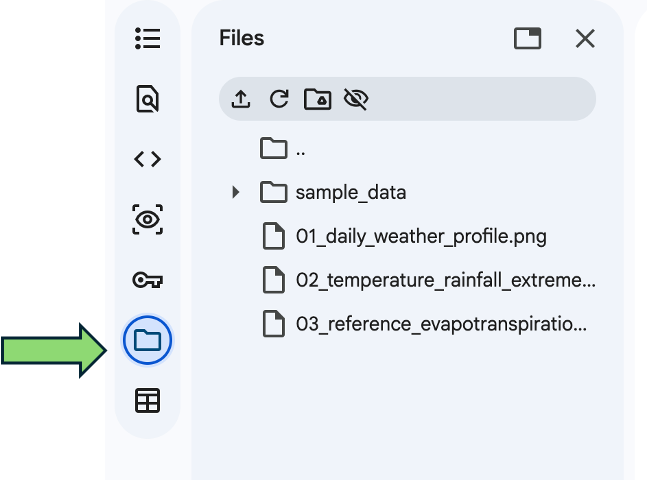

[Click to submit your output files](https://forms.gle/gpTMXTnTPS5RAf7v6)

## Important: Run the Cells in Order

Python notebooks run sequentially. Later cells often depend on variables or results created in earlier cells.

If a previous cell fails or is not run, the cells that follow will most likely fail as well.

When an error occurs:

1. Stop at the first cell that failed.
2. Correct the error in that cell.
3. Run the corrected cell again.
4. Confirm that it finishes successfully.
5. Rerun the cells below it in order.

Do not continue running later cells while an earlier cell still contains an error.

## Personalization Errors

If you receive either of the following errors:

> **Personalization not completed correctly.**

or

> **NameError: name 'selected_station' is not defined**

return to [Student Personalization](#return), correct or complete your information, and run the personalization cells again.

After the personalization cells run successfully, return to the section where the error occurred and rerun the required cells.

## Unfinished TODO Error

If you receive the following error:

> **NameError: name 'YOUR_CODE_HERE' is not defined**

you have reached a **TODO — YOUR TURN** line that has not been completed.

To resolve the error:

1. Read the hint immediately above `YOUR_CODE_HERE`.
2. Replace `YOUR_CODE_HERE` with the required Python expression.
3. Do not place your answer inside quotation marks unless the instructions specifically ask for text.
4. Run the completed cell again.
5. After it runs successfully, rerun the cells below it in order.

Do not delete the entire line or skip the cell. Later sections of the notebook may depend on the result created by that line.